
# **Skill-Luck Decomposition via Linear Combination Code**
### This code block finds the q_skill (and luck_share) value for each season of each league. The output is a CSV file with the league, season, name of metric (metric_name), value for the metric based on real data (metric_real), value for the metric based on pure skill data (metric_skill), value for the metric based on pure luck data (metric_luck), q_skill, and luck_share.

In [2]:
# ============================================================
# Skill–Luck Decomposition
# ============================================================

import pandas as pd
import numpy as np

# ------------------------- INPUTS ---------------------------
# Spearman (use spearman_r, not spearman_p)
SPEARMAN_SKILL = "/mnt/data/us_pure_skill_spearman.csv"
SPEARMAN_LUCK  = "/mnt/data/us_coin_flip_home_bias_v1_spearman.csv"
SPEARMAN_REAL  = "/mnt/data/us_combined_spearman.csv"

# Upset frequency (already aggregated to season-level)
UPSET_REAL_AGG  = "/mnt/data/us_combined_upset_frequency.csv"
UPSET_SKILL_AGG = "/mnt/data/us_pure_skill_upset_frequency.csv"
UPSET_LUCK_AGG  = "/mnt/data/us_coin_flip_home_bias_v1_upset_frequency.csv"

# Standard Deviation Win Rate NEED TO ADD CODE FOR THIS SECTION
SD_REAL  = "/mnt/data/sd_win_rate_us_actual.csv"
SD_SKILL = "/mnt/data/sd_win_rate_us_pure_luck_home_bias.csv"
SD_LUCK  = "/mnt/data/sd_win_rate_us_pure_skill.csv"

# Output
OUTPUT_CSV = "/mnt/data/skill_luck_decomposition.csv"
CLAMP_0_1 = False  # set True if you want q clamped to [0,1] in the saved CSV

# 1. Helper: Load in the spearman files

def load_spearman_minimal(path):
    """
    Expect columns: league, season, spearman_r
    Returns: league, season, team, metric_value (from spearman_r)
    """
    df = pd.read_csv(path, usecols=["league", "season", "spearman_r"])
    out = df.rename(columns={"spearman_r": "metric_value"})
    out["team"] = "all"
    return out[["league", "season", "team", "metric_value"]]


# 2. Helper: Load in the upset frequency files

def load_upset_agg_minimal(path):
    """
    Expect columns: league, season, upset_frequency
    Returns: league, season, team, metric_value (from upset_frequency)
    """
    df = pd.read_csv(path, usecols=["league", "season", "upset_frequency"])
    out = df.rename(columns={"upset_frequency": "metric_value"})
    out["team"] = "all"
    return out[["league", "season", "team", "metric_value"]]

# 3. Helper: Load in the standard deviation files

def load_sd_minimal(path):
    """
    Expect columns: league, season, std_win_rate
    Returns: league, season, metric_value (from std_win_rate)
    """
    df = pd.read_csv(path, usecols=["league", "team", "std_win_rate"])
    out = df.rename(columns={"std_win_rate": "metric_value"})
    out["season"] = "all"
    return out[["league", "season", "team", "metric_value"]]

# 4. Helper: Compute q = (real - luck) / (skill - luck) per (league, season).

def compute_q(metric_name, df_skill, df_luck, df_real, clamp=CLAMP_0_1):
    key = ["league", "season", "team"]
    merged = (
        df_real.merge(df_skill, on=key, how="outer", suffixes=("_real","_skill"))
               .merge(df_luck,  on=key, how="outer")
               .rename(columns={
                   "metric_value": "metric_luck",
                   "metric_value_real": "metric_real",
                   "metric_value_skill": "metric_skill"
               })
    )
    denom = merged["metric_skill"] - merged["metric_luck"]  # define denominator
    with np.errstate(divide='ignore', invalid='ignore'):
        q = (merged["metric_real"] - merged["metric_luck"]) / denom # define q
    q = q.where(~np.isclose(denom, 0.0), np.nan)

    if clamp: # clamp to be between 0 and 1 if wanted
        q = q.clip(0, 1)

    merged["metric_name"] = metric_name
    merged["q_skill"] = q
    merged["luck_share"] = 1 - q # define luck_share = 1 - q
    merged[["q_skill","luck_share"]] = merged[["q_skill","luck_share"]].round(4)

    return merged[[
        "league","season", "team", "metric_name",
        "metric_real","metric_skill","metric_luck",
        "q_skill","luck_share"
    ]]

# 5. Compute q for spearman:

sp_skill = load_spearman_minimal(SPEARMAN_SKILL)
sp_luck  = load_spearman_minimal(SPEARMAN_LUCK)
sp_real  = load_spearman_minimal(SPEARMAN_REAL)

spearman_out = compute_q("spearman_r", sp_skill, sp_luck, sp_real)

# 6. Compute q for upset frequency:

up_skill = load_upset_agg_minimal(UPSET_SKILL_AGG)
up_luck  = load_upset_agg_minimal(UPSET_LUCK_AGG)
up_real  = load_upset_agg_minimal(UPSET_REAL_AGG)

upset_out = compute_q("upset_frequency", up_skill, up_luck, up_real)

# 7. Compute q for standard deviation for win rate:

sd_skill = load_sd_minimal(SD_SKILL)
sd_luck  = load_sd_minimal(SD_LUCK)
sd_real  = load_sd_minimal(SD_REAL)

sd_out = compute_q("std_win_rate", sd_skill, sd_luck, sd_real)

# 8. Combine and save results:

results = pd.concat([spearman_out, upset_out, sd_out], ignore_index=True)
results.to_csv(OUTPUT_CSV, index=False)
print(f"Saved: {OUTPUT_CSV}")
print(results.head(10))


Saved: /mnt/data/skill_luck_decomposition.csv
  league season team metric_name  metric_real  metric_skill  metric_luck  \
0    MLB   1980  all  spearman_r       0.6634        0.9553       0.0424   
1    MLB   1981  all  spearman_r       0.4263        0.9121       0.3004   
2    MLB   1982  all  spearman_r       0.3734        0.9580       0.2058   
3    MLB   1983  all  spearman_r       0.3922        0.9573      -0.1736   
4    MLB   1984  all  spearman_r       0.2238        0.9200       0.0554   
5    MLB   1985  all  spearman_r       0.6450        0.9409       0.1728   
6    MLB   1986  all  spearman_r       0.2096        0.9452      -0.2924   
7    MLB   1987  all  spearman_r       0.3753        0.9798       0.0228   
8    MLB   1988  all  spearman_r       0.4492        0.9587       0.1409   
9    MLB   1989  all  spearman_r       0.4447        0.9438      -0.2474   

   q_skill  luck_share  
0   0.6802      0.3198  
1   0.2058      0.7942  
2   0.2228      0.7772  
3   0.5003      0

# Visualizations Code Block
## This code block will output bar charts and heat maps based on the skill_luck_decomposition.csv.

Clamped 33 rows to [0,1] for visualization.


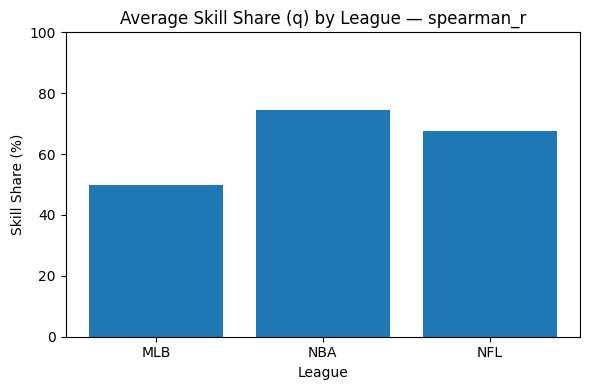

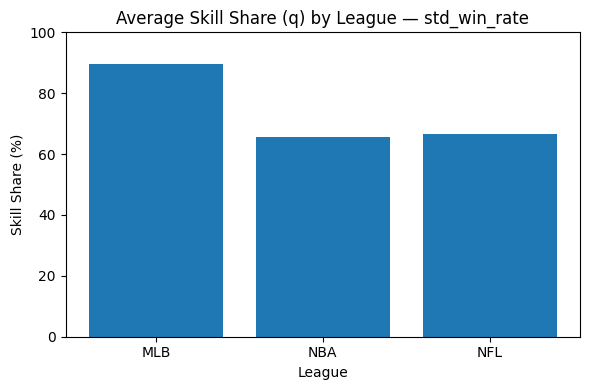

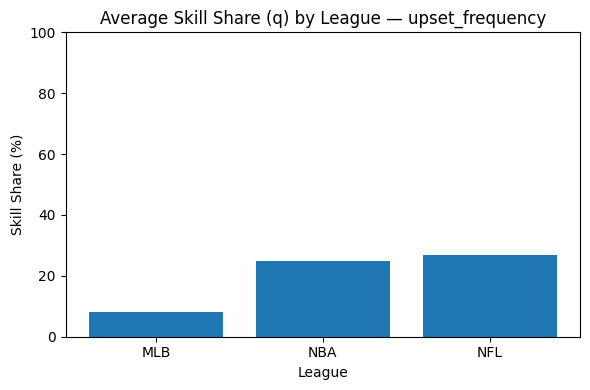

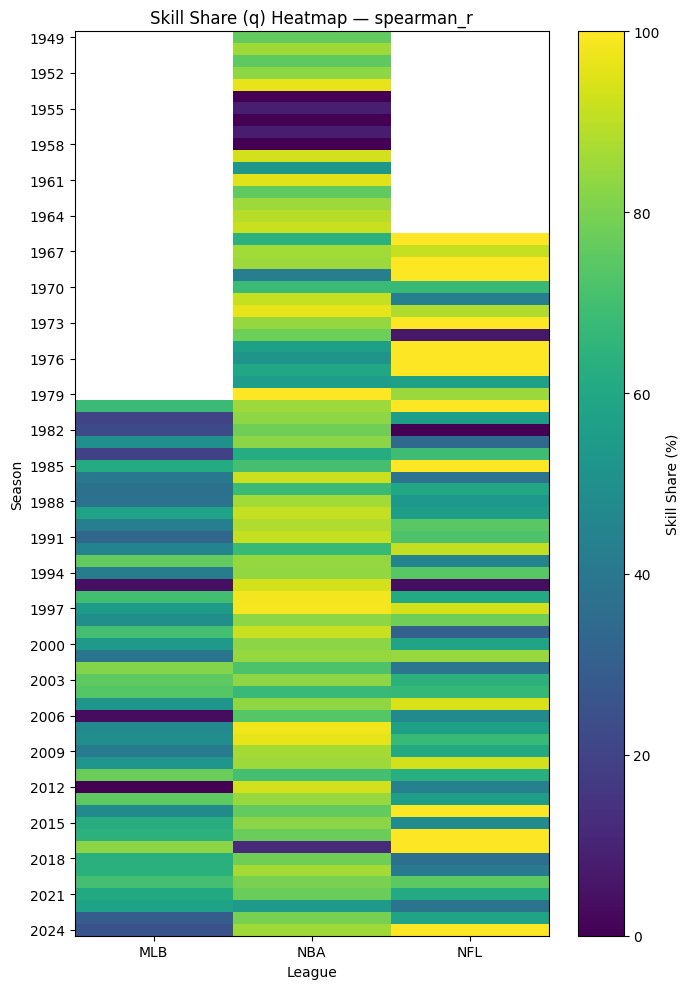

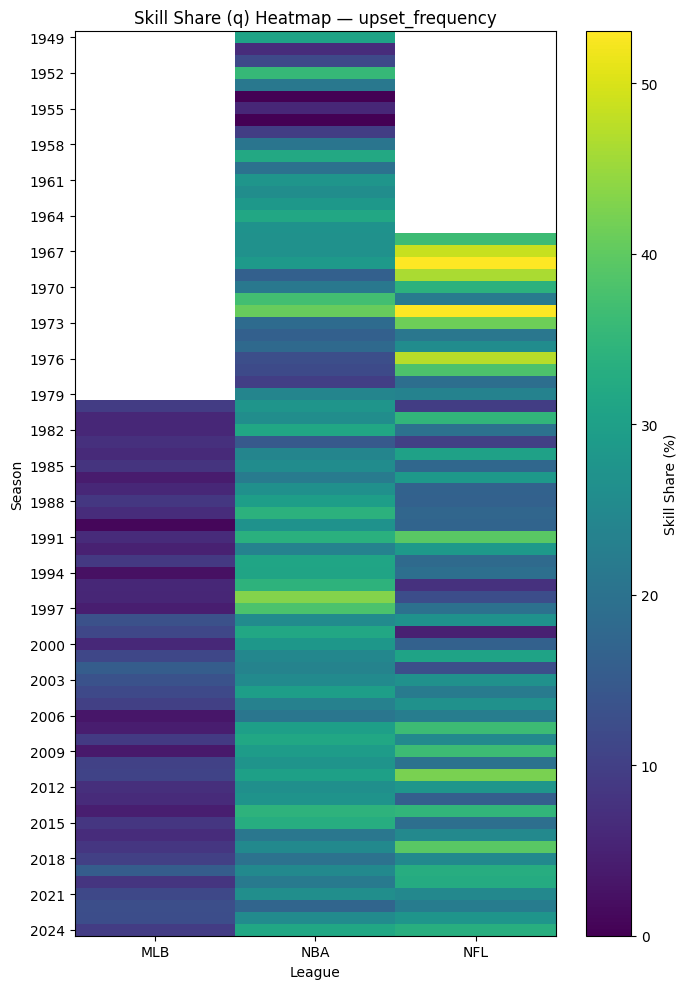

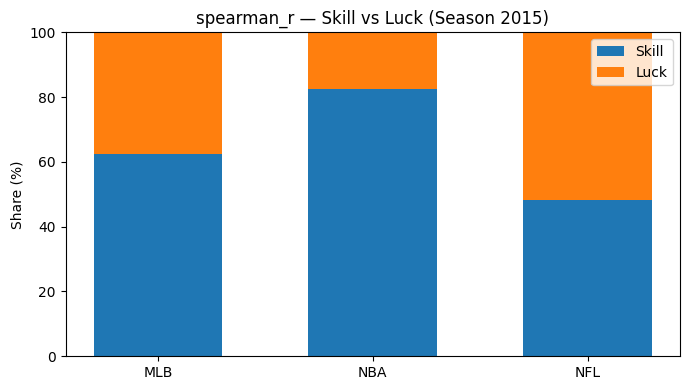

[std_win_rate] No data for season 2015. Skipping.


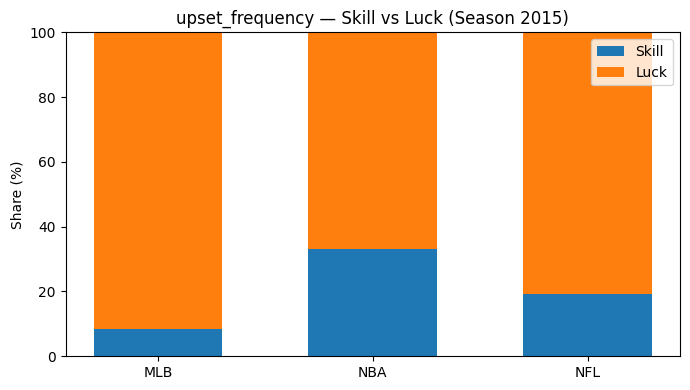


Average skill share (q, CLAMPED) by metric and league:
    metric_name league  q_skill_mean  q_skill_mean_pct
     spearman_r    MLB      0.499993              50.0
     spearman_r    NBA      0.745337              74.5
     spearman_r    NFL      0.675231              67.5
   std_win_rate    MLB      0.896806              89.7
   std_win_rate    NBA      0.655678              65.6
   std_win_rate    NFL      0.667397              66.7
upset_frequency    MLB      0.080693               8.1
upset_frequency    NBA      0.247817              24.8
upset_frequency    NFL      0.268764              26.9


In [3]:
# Visualizations from skill luck decomposition
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob

# 1. Inputs / Outputs
CSV_PATH   = "/mnt/data/skill_luck_decomposition.csv"
CLAMP_Q_01 = True      # clamp q to [0,1] for visuals/summary
OUT_DIR    = "/mnt/data/skill_luck_figs"

# 2. Load in files
if not os.path.exists(CSV_PATH):
    print("File not found:", CSV_PATH)
    print("Here are CSVs under /mnt/data:")
    for p in sorted(glob.glob("/mnt/data/*.csv")):
        print(" -", p)
    raise SystemExit

df = pd.read_csv(CSV_PATH)

# 3. Check column names
required = ["league","metric_name","q_skill"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["league"] = df["league"].astype(str).str.upper().str.strip()
if "season" in df.columns:
    df["season"] = pd.to_numeric(df["season"], errors="coerce")
df["q_skill"] = pd.to_numeric(df["q_skill"], errors="coerce")
if "luck_share" not in df.columns:
    df["luck_share"] = 1 - df["q_skill"]

# 4. Clamp values to be in [0,1] (to make sense visually)
if CLAMP_Q_01:
    df["q_skill_clamped"] = df["q_skill"].clip(0, 1)
    df["luck_share_clamped"] = 1 - df["q_skill_clamped"]
    df["q_was_clamped"] = (df["q_skill"] != df["q_skill_clamped"])
    print(f"Clamped {int(df['q_was_clamped'].sum())} rows to [0,1] for visualization.")
else:
    df["q_skill_clamped"] = df["q_skill"]
    df["luck_share_clamped"] = df["luck_share"]
    df["q_was_clamped"] = False


# 5. Bar charts: average q by league for each metric
metrics = sorted(df["metric_name"].dropna().unique())
for metric in metrics:
    sub = df[df["metric_name"] == metric]
    bar_data = (
        sub.groupby("league", as_index=False)["q_skill_clamped"]
           .mean()
           .sort_values("league")
    )
    plt.figure(figsize=(6,4))
    plt.bar(bar_data["league"], bar_data["q_skill_clamped"]*100)
    plt.title(f"Average Skill Share (q) by League — {metric}")
    plt.xlabel("League")
    plt.ylabel("Skill Share (%)")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

# 6. Heatmaps: q across seasons (rows) and leagues (cols) for each metric
has_season = "season" in df.columns and df["season"].notna().any()
if has_season:
    for metric in metrics:
        sub = df[df["metric_name"] == metric]
        if sub["season"].notna().any():
            piv = (
                sub.pivot_table(index="season", columns="league",
                                values="q_skill_clamped", aggfunc="mean")
                   .sort_index()
            )
            M = piv.to_numpy()
            if np.isnan(M).all():
                continue

            fig_h = max(3, min(10, 0.4*len(piv.index)+2))
            plt.figure(figsize=(7, fig_h))
            ax = plt.gca()
            im = ax.imshow(M*100, aspect="auto", interpolation="nearest")
            ax.set_title(f"Skill Share (q) Heatmap — {metric}")
            ax.set_xlabel("League")
            ax.set_ylabel("Season")

            ax.set_xticks(np.arange(len(piv.columns)))
            ax.set_xticklabels(piv.columns.tolist())
            seasons = piv.index.values
            if len(seasons) > 25:
                step = max(1, len(seasons)//25)
                idxs = np.arange(0, len(seasons), step)
                ax.set_yticks(idxs)
                ax.set_yticklabels(seasons[idxs].astype(int))
            else:
                ax.set_yticks(np.arange(len(seasons)))
                ax.set_yticklabels(seasons.astype(int))

            cbar = plt.colorbar(im)
            cbar.set_label("Skill Share (%)")
            plt.tight_layout()
            plt.show()


# 7. Stacked bars (skill vs luck) for a specific season per metric
SELECTED_SEASON = 2015  # change this to any season
if has_season:
    for metric in metrics:
        sub = df[df["metric_name"] == metric]

        # filter to selected_season
        sub_year = sub[sub["season"] == SELECTED_SEASON]

        # if no data for that season for that league, output no data
        if sub_year.empty:
            print(f"[{metric}] No data for season {SELECTED_SEASON}. Skipping.")
            continue

        block = (
            sub_year
            .groupby("league", as_index=False)[["q_skill_clamped","luck_share_clamped"]]
            .mean()
            .sort_values("league")
        )

        x = np.arange(len(block["league"]))
        width = 0.6

        plt.figure(figsize=(7,4))
        plt.bar(x, block["q_skill_clamped"]*100, width, label="Skill")
        plt.bar(x, block["luck_share_clamped"]*100, width,
                bottom=block["q_skill_clamped"]*100, label="Luck")
        plt.xticks(x, block["league"])
        plt.ylim(0, 100)
        plt.title(f"{metric} — Skill vs Luck (Season {SELECTED_SEASON})")
        plt.ylabel("Share (%)")
        plt.legend()
        plt.tight_layout()
        plt.show()


# 8. Summary of values
summary = (
    df.groupby(["metric_name","league"], as_index=False)["q_skill_clamped"]
      .mean()
      .rename(columns={"q_skill_clamped":"q_skill_mean"})
)
summary["q_skill_mean_pct"] = (summary["q_skill_mean"]*100).round(1)
print("\nAverage skill share (q, CLAMPED) by metric and league:")
print(summary.sort_values(["metric_name","league"]).to_string(index=False))
